In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba
import sys
import math
import json
import os
import yaml
from scipy.interpolate import CubicSpline
# plotting
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import colorsys
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import dill as pickle

# import FuncToggle
import FuncPatternQuant.dimensional as dimFuncPatternQuant
import FuncPatternQuant.nondimensional4D as nd4FuncPatternQuant
import FuncToggle.dimensional as dimFuncToggle
import FuncToggle.nondimensional4D as nd4FuncToggle
import FuncAnalytical.dimensional as dimFuncAnalytical
import FuncAnalytical.nondimensional4D as nd4FuncAnalytical
import FuncPatternQuant.nondimensional3D as nd3FuncPatternQuant
import FuncToggle.nondimensional3D as nd3FuncToggle
import FuncAnalytical.nondimensional3D as nd3FuncAnalytical
import FuncDim

import FuncSelfActivatingNode as FuncSAN

ModuleNotFoundError: No module named 'FuncAnalyticalv2'

In [301]:
p = 2
VN = 1
Nstar = 1
kn = 0.2
h = 2
alpha_star = FuncSAN.find_alpha_star(VN, Nstar, kn)
n_min = FuncSAN.find_n_min(alpha_star, p)


In [302]:
m_min = 0 
m_max = 4
m_values = np.linspace(m_min, m_max, 2000)
m_crit = FuncSAN.find_critical_m_3nd(p,alpha_star,h)
num_values = 100
# n_min = FuncSAN.find_n_min(alpha, p)

# find n1 fixed point from m values
zero_m_values = np.linspace(m_min,m_max,num_values)
bist_m_values = np.linspace(m_crit,m_max,num_values)

# initiate solution arrays
zero_n_solutions = np.zeros(len(zero_m_values)) # n=0 is a solution for all alpha
upper_n_solutions = np.zeros(len(bist_m_values)) # stable upper solution
lower_n_solutions = np.zeros(len(bist_m_values)) # unstable lower solution

for i in range(len(zero_m_values)):
    m_value = zero_m_values[i]
    alpha = FuncSAN.find_alpha(alpha_star, m_value, h)
    zero_n_solutions[i] = fsolve(FuncSAN.find_dndt_tilde,0,args=(p,alpha))[0]

for i in range(len(bist_m_values)):
    m_value = bist_m_values[i]
    alpha = FuncSAN.find_alpha(alpha_star, m_value, h)
    upper_solution, lower_solution = fsolve(FuncSAN.find_dndt_tilde,20000*n_min,args=(p,alpha))[0], fsolve(FuncSAN.find_dndt_tilde,n_min/6,args=(p,alpha))[0]
    if upper_solution == lower_solution:
        print(i,"only found 1 solution")
    
    upper_n_solutions[i] = upper_solution
    lower_n_solutions[i] = lower_solution

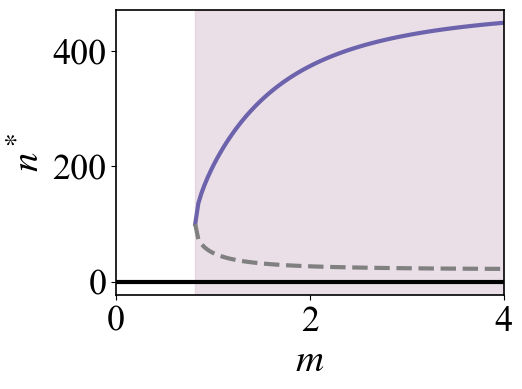

In [ ]:
fig, ax = plt.subplots(figsize=(5,3.7))

plt.plot(zero_m_values,zero_n_solutions,color='k')
plt.plot(bist_m_values,upper_n_solutions,color='purple')
plt.plot(bist_m_values,lower_n_solutions,color='grey',ls='--')

# plt.axvline(alpha_crit,color='k',ls='--')
plt.axvspan(m_crit, m_max, color='lilac', alpha=0.5)
plt.xlabel('$m$')
plt.ylabel('$n^*$')
plt.xlim(m_min, m_max)
plt.yticks([0,2,4], labels=['0','200','400'])
plt.xticks([0,2,4])


# plt.xscale('log')
# plt.axhline(VN/kn)
# plt.title('p = ' + str(p) + ', h = ' + str(h) + ', $\\alpha^*$ = ' + str(alpha_star))
plt.savefig(savefigpath + 'SAN_bifurc.png', dpi=1000, bbox_inches='tight')

# 1D simulations

In [109]:
t_factor = 1000

In [245]:
# %%%%%%%%%%%%%%%%%%%%% Physical Parameters %%%%%%%%%%%%%%%%%%%%%
L0 = 100 # initial length of tissue
Lf = 1000
epsilon = 0.8 # anisotropy parameter
g_max =  0.00001 * t_factor


# morphogen parameters
D = 0.25 * t_factor
k = 0.00035 * t_factor
sourceSize = 20
VM = 0.006 * t_factor


# %%%%%%%%%%%% Gene Regulatory Network parameters %%%%%%%%%%%%
VN = 0.0002 * t_factor # production rate of gene 1
kn = 0.000001 * t_factor# degradation rate of gene 1

# critical concentrations
Mstar = 0.5
Nstar = 1
# Hill coefficients
p = 2
h = 4

# find non-dimensional parameters
vm, vn = FuncSAN.find_nd_2d_parameters(VM, Mstar, VN, Nstar)
alpha_star = FuncSAN.find_alpha_star(VN, Nstar, kn)

# %%%%%%%%%%%%%%%%%%%%% Simulation Parameters %%%%%%%%%%%%%%%%%%%%%
N = 101
t_max = (1+epsilon)*np.log(Lf/L0)/(g_max)
dt_factor = 0.95
store_no = 1000 # the number of counts at which I store the results
store_no_ng = 200000 # the number of counts at which I store the results for no growth case

# %%%%%%%%%%%% initial conditions %%%%%%%%%%%%
x0 = np.linspace(0,L0,N)
m_init = nd3FuncAnalytical.find_m_ana_SS(vm,k,D,sourceSize,N,L0,x0,ratio_given=False)
n_init = np.zeros(N)
n_init[:int(N/3)] = (vn/kn)


# final space
xf = np.linspace(0,Lf,N)

# patterning threshold
fraction = 0.4 # for threshold of boundary 

# 0D 
dt_factor_0D = 0.005

In [ ]:


# calculate simulation parameters
N_1, N_2, dy, w0, dt, count_max, dt_store = FuncSAN.calculate_useful_simulation_parameters(N,L0,dt_factor,D,k,g_max,kn,sourceSize,t_max,store_no)
N_1, N_2, dy, w0, dt_ng, count_max_ng, dt_store_ng = FuncSAN.calculate_useful_simulation_parameters_no_growth(N,L0,dt_factor,D,k,kn,sourceSize,store_no_ng,t_max_factor = 10)

# save a dictionary for the system parameters
System_Parameters = {"D":D/t_factor,"k":k/t_factor,"VM":VM/t_factor,"L0":L0,"Lf":Lf,"sourceSize":sourceSize,"epsilon":epsilon,"vn":vn/t_factor,"kn":kn/t_factor,"Mstar":Mstar,"p":p,"h":h,"g0":g_max/t_factor,"fraction":fraction}
Simulation_Parameters = {"dt":dt,"N":N,"dt_store":dt_store,"t_max":t_max,"dt_ng":dt_ng}

# np.save('PmetersUsarametersUsed/SF_ICs0_System_Parameters.npy', System_Parameters)
# np.save('Paraed/SF_ICs0_Simulation_Parameters.npy', Simulation_Parameters)


# stability checks
FuncSAN.von_Neumann_and_growth_check(dt, D, dy, k, g_max, kn, epsilon)
FuncDim.growth_dy_check(L0,Lf,N)

lam = np.sqrt(D/k) # characteristic length scale of morphogen gradient

growth stability 1.0551862403714257e-05
vN 1.9000189933523268
Stable
initial dy, final dy 1.0 6.0
k real 0.00022 sim 0.00035
lambda real 25 sim 26.72612419124244
growth rate real 1e-05 sim 1e-05
tissue length real 100 sim 100
anisotropy parameter real 0.6 sim 0.8
GRN production rates real 7.5e-05 sim 0.0002 0.0002
GRN degradation rates real 2.5e-05 sim 1e-06 1e-06


In [226]:
System_Parameters

{'D': 0.25,
 'k': 0.00035,
 'VM': 0.006,
 'L0': 100,
 'Lf': 600,
 'sourceSize': 20,
 'epsilon': 0.8,
 'vn': 0.0002,
 'kn': 1e-06,
 'Mstar': 0.5,
 'p': 2,
 'h': 4,
 'g0': 1e-05,
 'fraction': 0.4}

In [227]:
# System_Parameters = np.load('ParametersUsed/SF_MBM_System_Parameters.npy', allow_pickle=True).item()

In [228]:
alpha_star

200.0

In [229]:
m_min = 0 
m_max = 4
alpha_star = FuncSAN.find_alpha_star(VN, Nstar, kn)
m_values = np.linspace(m_min, m_max, 100)
m_crit = FuncSAN.find_critical_m_3nd(p,alpha_star,h)
num_values = 500
# n_min = FuncSAN.find_n_min(alpha, p)

# find n1 fixed point from m values
zero_m_values = np.linspace(m_min,m_max,num_values)
bist_m_values = np.linspace(m_crit,m_max,num_values)

# initiate solution arrays
zero_n_solutions = np.zeros(len(zero_m_values)) # n=0 is a solution for all alpha
upper_n_solutions = np.zeros(len(bist_m_values)) # stable upper solution
lower_n_solutions = np.zeros(len(bist_m_values)) # unstable lower solution



for i in range(len(zero_m_values)):
    m_value = zero_m_values[i]
    alpha = FuncSAN.find_alpha(alpha_star, m_value, h)
    zero_n_solutions[i] = fsolve(FuncSAN.find_dndt_tilde,0,args=(p,alpha))[0]


for i in range(len(bist_m_values)):
    m_value = bist_m_values[i]
    alpha = FuncSAN.find_alpha(alpha_star, m_value, h)
    upper_solution, lower_solution = fsolve(FuncSAN.find_dndt_tilde,20000*n_min,args=(p,alpha))[0], fsolve(FuncSAN.find_dndt_tilde,n_min/1.2,args=(p,alpha))[0]
    if upper_solution == lower_solution:
        print(i,"only found 1 solution")
    
    upper_n_solutions[i] = upper_solution
    lower_n_solutions[i] = lower_solution

10 only found 1 solution
11 only found 1 solution
15 only found 1 solution
17 only found 1 solution
18 only found 1 solution
21 only found 1 solution
22 only found 1 solution
23 only found 1 solution
32 only found 1 solution
34 only found 1 solution
35 only found 1 solution
36 only found 1 solution


(0.0, 4.0)

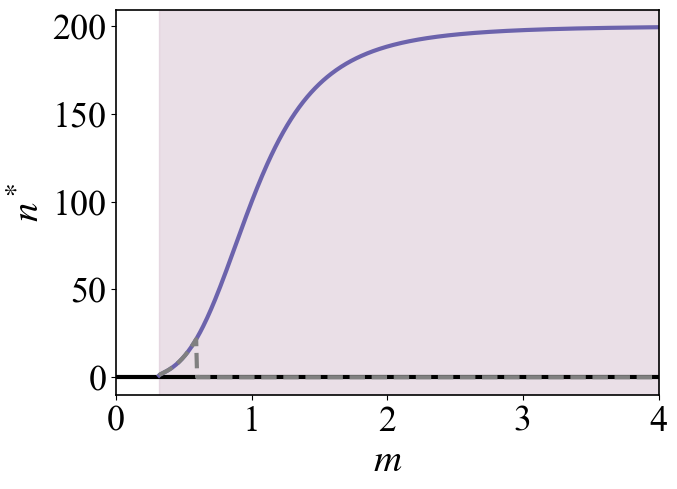

In [ ]:
plt.plot(zero_m_values,zero_n_solutions,color='k')
plt.plot(bist_m_values,upper_n_solutions,color='purple')
plt.plot(bist_m_values,lower_n_solutions,color='grey',ls='--')

# plt.axvline(alpha_crit,color='k',ls='--')
plt.axvspan(m_crit, m_max, color='lilac', alpha=0.5)
plt.xlabel('$m$')
plt.ylabel('$n^*$')
plt.xlim(m_min, m_max)
# plt.yscale('log')

In [231]:
System_Parameters = {'D': D/t_factor,'k': k/t_factor,'VM': VM/t_factor,'L0': L0, 'sourceSize': sourceSize,'VN': VN/t_factor,'kn': kn/t_factor,'Mstar': Mstar,'Nstar': Nstar,'p': p,'h': h,'g_max': g_max/t_factor, 'fraction': fraction}
Simulation_Parameters = {"dt":dt,"N":N,"dt_store":dt_store,"t_max":t_max,"dt_ng":dt_ng}

In [232]:
System_Parameters

{'D': 0.25,
 'k': 0.00035,
 'VM': 0.006,
 'L0': 100,
 'sourceSize': 20,
 'VN': 0.0002,
 'kn': 1e-06,
 'Mstar': 0.5,
 'Nstar': 1,
 'p': 2,
 'h': 4,
 'g_max': 1e-05,
 'fraction': 0.4}

In [233]:
# % 'D': 0.25, 'k': 0.00035, 'VM': 0.006, 'L0': 100, 'Lf': 600, 'sourceSize': 20, 'epsilon': 0.8, 'vn': 0.0002, 'kn': 1e-06, 'Mstar': 0.5, 'p': 2, 'h': 4, 'g0': 1e-05, 'fraction': 0.4

In [234]:
# find bistable region
m_crit = FuncSAN.find_critical_m_3nd(p,alpha_star,h)
x_crit = dimFuncToggle.find_x_critical_from_M_critical(m_init,m_crit,x0,N)

# x_crit_f = dimFuncToggle.find_x_critical_from_M_critical(mArray_g[-1,:],m_crit,xArray_g[-1,:],N)
# x_crit, x_crit_f

find_x_critical_from_M_critical: Mcritical is too low  <M(x=N) - not reached for this morphogen gradient


## run solver

In [235]:
timeArray_eff, nArray_eff = FuncSAN.n_solver_NoGrowth_fixedm_2nd(N,dt_ng,vn,kn+g_max,p,h,store_no,n_init,m_init,count_max_ng)

# nondimensional growing code
timeArray, xArray, mArray, nArray, x_YArray, LArray, wArray = FuncSAN.n_solver_ConstantGrowth_fixed_source_2nd(N,N_1,N_2,w0,D,k,vm,epsilon,sourceSize,dt,dy,vn,kn,h,p,L0,store_no,m_init,nArray_eff[-1,:],count_max,g_max)
n_amp_eff = vn * nd3FuncToggle.pos_hill_function(np.max(m_init),h) / (kn+g_max) 
n_boundaryArray = dimFuncPatternQuant.find_gene_boundaryArray(nArray,xArray,sourceSize,fraction,norm_value=n_amp_eff)

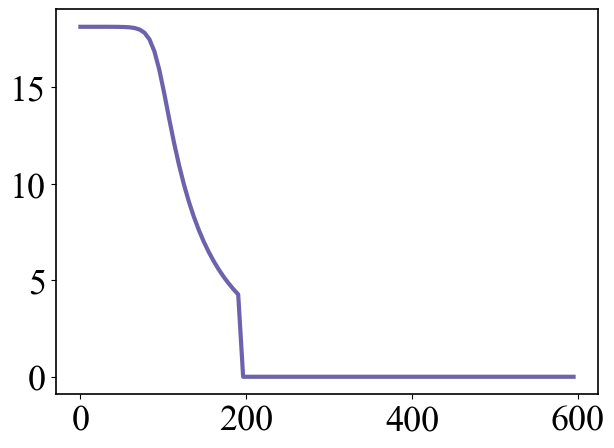

In [ ]:
plt.plot(xArray[-1,:],nArray[-1,:],color='purple')

(0.0, 600.0)

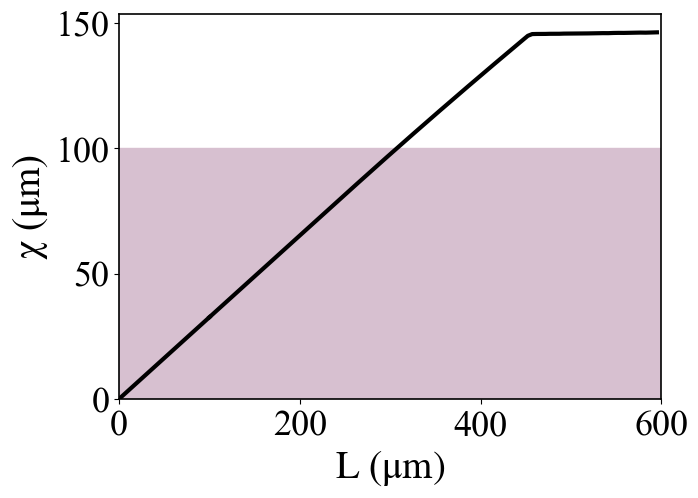

In [ ]:
plt.plot(LArray, n_boundaryArray, color='k')
plt.xlabel('$\\mathrm{L}$ ($\\mathrm{\\mu m})$')
plt.ylabel('$\\mathrm{\\chi}$ ($\\mathrm{\\mu m}$)')
plt.axhspan(0,x_crit,color='lilac',label='Bistable region')

plt.plot([0,L0], [0,n_boundaryArray[0]],color='black')
plt.ylim(ymin=0)
plt.xlim(0,Lf)

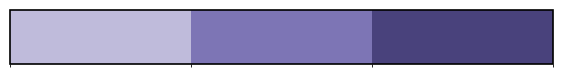

In [ ]:
L_values = [100, 200, 300] # run a 1D simulation with initial conditions at SS

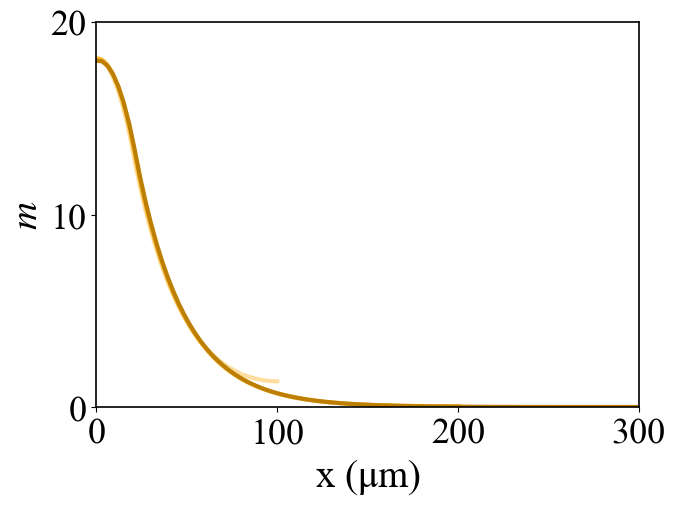

In [ ]:
# growing simulation: morphogen profiles - absolute position

fig, ax = plt.subplots()

for i in range(len(L_values)):
    L_val = L_values[i]
    time_index = np.clip(np.searchsorted(LArray,L_val),0,len(LArray)-1)
    plt.plot(xArray[time_index,:],mArray[time_index,:],color=M_coloursArray[i],label=f'L={L_val} $\\mathrm{{\\mu m}}$')

    # plt.plot(xArray_1D[time_index,:],mArray_1D[time_index,:])

# plt.axhspan(m_critical1,mArray_1D_IC[time_index,0], color='lilac', alpha=0.3, label='Bistable region')
plt.xlabel('x ($\\mathrm{\\mu m}$)')
plt.ylabel('$m$')
plt.xlim(0,L_values[-1])
plt.ylim(ymin=0)


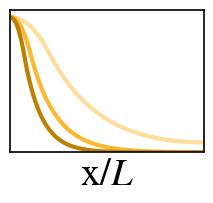

In [ ]:
# growing simulation: morphogen profiles - relative position
fig, ax = plt.subplots(figsize=[2.5,1.85])


for i in range(len(L_values)):
    L_val = L_values[i]
    time_index = np.clip(np.searchsorted(LArray,L_val),0,len(LArray)-1)
    plt.plot(xArray[time_index,:]/L_val,mArray[time_index,:],color=M_coloursArray[i],label=f'L={L_val} $\\mathrm{{\\mu m}}$')
    # plt.plot(xArray_1D[time_index,:],mArray_1D[time_index,:])


plt.xlabel('$\\mathrm{x}/L$')
# plt.ylabel('$m$')
plt.xlim(0,1)
plt.ylim(ymin=0)
# ax.set_xticks([0,0.5,1.0])
# ax.set_xticklabels([0.0,0.5,1.0])
ax.set_yticks([])
ax.set_xticks([])




100
200
300


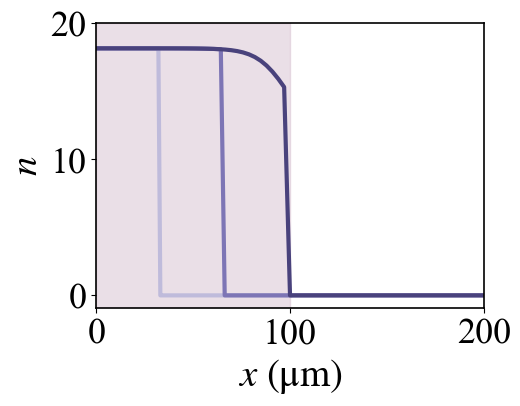

In [ ]:
for i in range(len(L_values)):
    L_val = L_values[i]
    print(L_val)
    time_index = np.clip(np.searchsorted(LArray,L_val),0,len(LArray)-1)
    plt.plot(xArray[time_index,:],nArray[time_index,:],color='purple'sArray[i])


# plt.plot(x0,nArray_eff[-1,:],color=N1_colour,alpha=0.5)


# plt.plot(xArray_g[time_index,:],nArray_g[time_index,:],color='purple'sArray[2])

# plt.plot(xArray_g[-1,:],nArray_relax[-1,:],color='red',ls=':')
# plt.plot(xArray_g[-1,:],nArray_relax[20,:],color='red',ls='--')


plt.xlabel('$x$ $(\\mathrm{\\mu m})$')
plt.ylabel('$n$')
plt.xlim(0,200)
plt.xticks([0,100,200])
plt.yticks([0,10,20])

plt.axvspan(0,x_crit, color='lilac', alpha=0.5)


[]

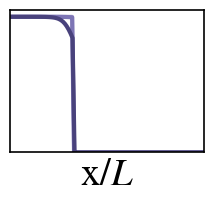

In [ ]:
# growing simulation: N1 and N2 profiles - relative position
fig, ax = plt.subplots(figsize=[2.5,1.85])

for i in range(len(L_values)):
    L_val = L_values[i]
    time_index = np.clip(np.searchsorted(LArray,L_val),0,len(LArray)-1)
    plt.plot(xArray[time_index,:]/L_val,nArray[time_index,:],color='purple'sArray[i])

    # plt.plot(xArray_1D_IC[time_index,:]/L_val,n1Array_1D_IC[time_index,:],color=N1_coloursArray[i],label=f'L={L_val} $\\mathrm{{\\mu m}}$')
    # plt.plot(xArray_1D_IC[time_index,:]/L_val,n2Array_1D_IC[time_index,:],color='purple'sArray[i],)


plt.xlabel('$\\mathrm{x}/L$')
# plt.ylabel('Normalised $\\mathrm{n_1}$, $\\mathrm{n_2}$')